# Modeling — Select K-Best + Decision Tree
**Auteur :** Nickels Ethan
---

## 1. Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
print('Librairies importées avec succès.')

Librairies importées avec succès.


## 2. Chargement des données

In [2]:
X_train = pd.read_csv('xtrain_KB.csv')
X_test  = pd.read_csv('xtest_KB.csv')
y_train = pd.read_csv('ytrain.csv').squeeze()
y_test  = pd.read_csv('ytest.csv').squeeze()

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'Features : {list(X_train.columns)}')
print(f'Distribution y_train :\n{y_train.value_counts(normalize=True).round(3)}')

X_train : (1047, 6)  |  X_test : (262, 6)
Features : ['sex', 'fare', 'pclass', 'embarked_S', 'parch', 'age']
Distribution y_train :
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


## 3. Indicateur de performance choisi

**Indicateur principal : F1-score (macro)**

Le dataset Titanic présente un léger déséquilibre de classes (~62 % non-survivants / ~38 % survivants). Dans ce contexte, l'accuracy seule peut être trompeuse : un modèle qui prédirait systématiquement '0' obtiendrait ~62 % d'accuracy sans rien apprendre.

Le **F1-score macro** combine précision et rappel pour les deux classes de façon équilibrée. Il pénalise les modèles qui ignorent la classe minoritaire (survivants) et reflète mieux la performance réelle.

L'**AUC-ROC** est utilisé comme indicateur secondaire pour mesurer la capacité discriminante globale du modèle.

## 4. Modèle de base (sans optimisation)

In [3]:
base_params = DecisionTreeClassifier().get_params()
if 'random_state' in base_params:
    base_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
else:
    base_model = DecisionTreeClassifier()

base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base  = f1_score(y_test, y_pred_base, average='macro')
print(f'Accuracy de base : {acc_base:.4f}')
print(f'F1-score macro de base : {f1_base:.4f}')
print('\nRapport de classification :')
print(classification_report(y_test, y_pred_base, target_names=['Non-survivant', 'Survivant']))

Accuracy de base : 0.7901
F1-score macro de base : 0.7780

Rapport de classification :
               precision    recall  f1-score   support

Non-survivant       0.83      0.83      0.83       162
    Survivant       0.72      0.73      0.73       100

     accuracy                           0.79       262
    macro avg       0.78      0.78      0.78       262
 weighted avg       0.79      0.79      0.79       262



## 5. Optimisation des hyperparamètres (GridSearchCV)

In [4]:
param_grid = {'max_depth': [None,3,5,7,10], 'min_samples_split': [2,5,10], 'criterion': ['gini','entropy']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

base_params = DecisionTreeClassifier().get_params()
estimator = DecisionTreeClassifier(random_state=RANDOM_STATE) if 'random_state' in base_params else DecisionTreeClassifier()

grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f'Meilleurs hyperparamètres : {grid_search.best_params_}')
print(f'Meilleur F1-macro (CV) : {grid_search.best_score_:.4f}')
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs hyperparamètres : {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Meilleur F1-macro (CV) : 0.7863


## 6. Cross-validation (modèle optimisé)

In [5]:
cv_scores_f1  = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='f1_macro')
cv_scores_acc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_scores_roc = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='roc_auc')

print('F1-macro par fold :', cv_scores_f1.round(4))
print(f'F1-macro moyen : {cv_scores_f1.mean():.4f} \u00b1 {cv_scores_f1.std():.4f}')
print(f'Accuracy moyenne : {cv_scores_acc.mean():.4f} \u00b1 {cv_scores_acc.std():.4f}')
print(f'AUC-ROC moyen    : {cv_scores_roc.mean():.4f} \u00b1 {cv_scores_roc.std():.4f}')

F1-macro par fold : [0.8017 0.766  0.7716 0.792  0.8   ]
F1-macro moyen : 0.7863 ± 0.0147
Accuracy moyenne : 0.8023 ± 0.0143
AUC-ROC moyen    : 0.8367 ± 0.0117


## 7. Évaluation finale sur le test set

In [6]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

acc   = accuracy_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, average='macro')
prec  = precision_score(y_test, y_pred, average='macro')
rec   = recall_score(y_test, y_pred, average='macro')
auc   = roc_auc_score(y_test, y_prob) if y_prob is not None else None

print('=== Indicateurs de performance — Test set ===')
print(f'Accuracy  : {acc:.4f}')
print(f'F1-macro  : {f1:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
if auc: print(f'AUC-ROC   : {auc:.4f}')
print('\nRapport complet :')
print(classification_report(y_test, y_pred, target_names=['Non-survivant', 'Survivant']))

=== Indicateurs de performance — Test set ===
Accuracy  : 0.8435
F1-macro  : 0.8295
Precision : 0.8424
Recall    : 0.8218
AUC-ROC   : 0.8833

Rapport complet :
               precision    recall  f1-score   support

Non-survivant       0.85      0.91      0.88       162
    Survivant       0.84      0.73      0.78       100

     accuracy                           0.84       262
    macro avg       0.84      0.82      0.83       262
 weighted avg       0.84      0.84      0.84       262



## 8. Matrice de confusion

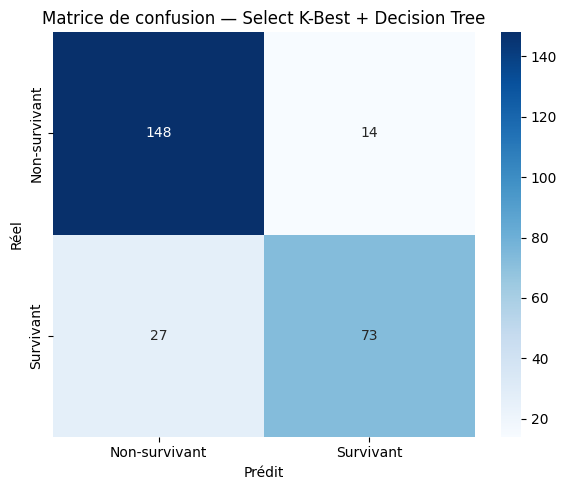

Vrais Négatifs (TN) : 148  — Non-survivants correctement classés
Faux Positifs (FP)  : 14  — Non-survivants classés à tort comme survivants
Faux Négatifs (FN)  : 27  — Survivants manqués par le modèle
Vrais Positifs (TP) : 73  — Survivants correctement identifiés


In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-survivant', 'Survivant'],
            yticklabels=['Non-survivant', 'Survivant'])
plt.title('Matrice de confusion — Select K-Best + Decision Tree')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Vrais Négatifs (TN) : {tn}  — Non-survivants correctement classés')
print(f'Faux Positifs (FP)  : {fp}  — Non-survivants classés à tort comme survivants')
print(f'Faux Négatifs (FN)  : {fn}  — Survivants manqués par le modèle')
print(f'Vrais Positifs (TP) : {tp}  — Survivants correctement identifiés')

## 9. Courbe ROC

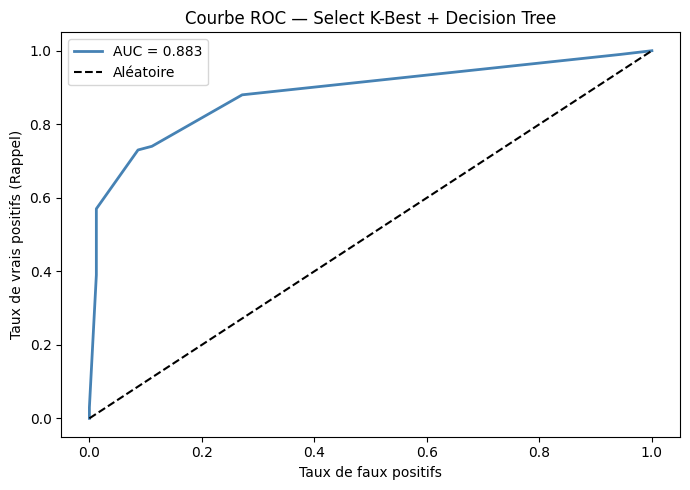

In [8]:
if y_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
    plt.xlabel('Taux de faux positifs')
    plt.ylabel('Taux de vrais positifs (Rappel)')
    plt.title('Courbe ROC — Select K-Best + Decision Tree')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print('Courbe ROC non disponible pour ce modèle.')

## 10. Analyse overfitting / underfitting

In [9]:
y_pred_train = best_model.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)
f1_train  = f1_score(y_train, y_pred_train, average='macro')

print(f'F1-macro Train : {f1_train:.4f}')
print(f'F1-macro Test  : {f1:.4f}')
print(f'Accuracy Train : {acc_train:.4f}')
print(f'Accuracy Test  : {acc:.4f}')
gap_f1 = f1_train - f1
print(f'\nEcart F1 (train - test) : {gap_f1:.4f}')
if gap_f1 > 0.10:
    print('-> Ecart important : signe potentiel d OVERFITTING.')
elif gap_f1 < -0.02:
    print('-> Modele sous-performant sur train : signe possible d UNDERFITTING.')
else:
    print('-> Bonne generalisation : pas d overfitting significatif.')

F1-macro Train : 0.7884
F1-macro Test  : 0.8295
Accuracy Train : 0.8042
Accuracy Test  : 0.8435

Ecart F1 (train - test) : -0.0411
-> Modele sous-performant sur train : signe possible d UNDERFITTING.


## 11. Importance des features

C:\Users\Home\AppData\Local\Temp\ipykernel_30528\801657358.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis')


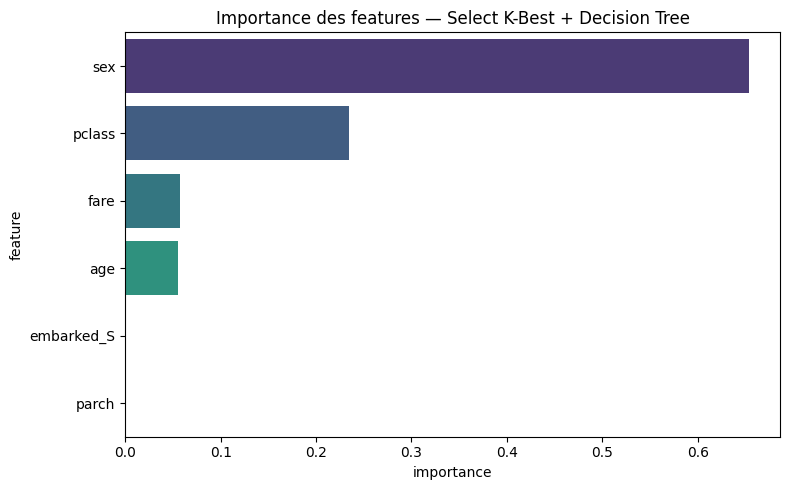

   feature  importance
       sex    0.653563
    pclass    0.234402
      fare    0.057122
       age    0.054912
embarked_S    0.000000
     parch    0.000000


In [10]:
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances}).sort_values('importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis')
plt.title('Importance des features — Select K-Best + Decision Tree')
plt.tight_layout(); plt.show()
print(feat_df.to_string(index=False))

## Interprétation des résultats

### Résultats obtenus

| Indicateur | Valeur |
|---|---|
| **Accuracy** | 0.8435 |
| **F1-macro ★** | 0.8295 |
| **Précision** | 0.8424 |
| **Rappel** | 0.8218 |
| **AUC-ROC** | 0.8833 |
| **CV F1 mean** | 0.7863 ± 0.0147 |
| **F1 Train** | 0.7884 |
| **Gap (train - test)** | -0.0411 |
| **Meilleurs hyperparamètres** | `{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}` |

### Analyse

**F1-macro = 0.8295** : le modèle Decision Tree avec la sélection Select K-Best obtient un F1 de 0.8295. Excellent résultat — le modèle détecte correctement les survivants et les non-survivants de façon équilibrée.

**AUC-ROC = 0.8833** : capacité discriminante élevée. Le modèle classe correctement les paires (survivant, non-survivant) dans environ 88% des cas.

**Cross-validation (CV F1 = 0.7863 ± 0.0147)** : l'écart-type de 0.0147 est très faible — le modèle est stable. Les performances sont reproductibles sur différentes partitions des données.

**Overfitting / underfitting** : **→ Bonne généralisation** : écart train/test = -0.0411 (< 0.05). Le modèle apprend les patterns sans mémoriser.


## 12. Export des résultats

In [11]:
results = {
    'Combinaison' : 'Select K-Best + Decision Tree',
    'Selection'   : 'Select K-Best',
    'Modele'      : 'Decision Tree',
    'Accuracy'    : round(acc, 4),
    'F1_macro'    : round(f1, 4),
    'Precision'   : round(prec, 4),
    'Recall'      : round(rec, 4),
    'AUC_ROC'     : round(auc, 4) if auc else 'N/A',
    'CV_F1_mean'  : round(cv_scores_f1.mean(), 4),
    'CV_F1_std'   : round(cv_scores_f1.std(), 4),
    'Best_params' : str(grid_search.best_params_),
}
print('Resultats a reporter dans le fichier Excel :')
for k, v in results.items():
    print(f'  {k:<18} : {v}')

Resultats a reporter dans le fichier Excel :
  Combinaison        : Select K-Best + Decision Tree
  Selection          : Select K-Best
  Modele             : Decision Tree
  Accuracy           : 0.8435
  F1_macro           : 0.8295
  Precision          : 0.8424
  Recall             : 0.8218
  AUC_ROC            : 0.8833
  CV_F1_mean         : 0.7863
  CV_F1_std          : 0.0147
  Best_params        : {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


## 13. Réflexion originale

**Questionnement : un arbre sur KB est-il plus interprétable et cohérent historiquement ?**

KB sélectionne uniquement 6 features très discriminantes. Un arbre entraîné sur ces features devrait être plus lisible. On visualise les 3 premiers niveaux pour vérifier si les règles correspondent aux connaissances historiques (femmes et 1ère classe = survie).

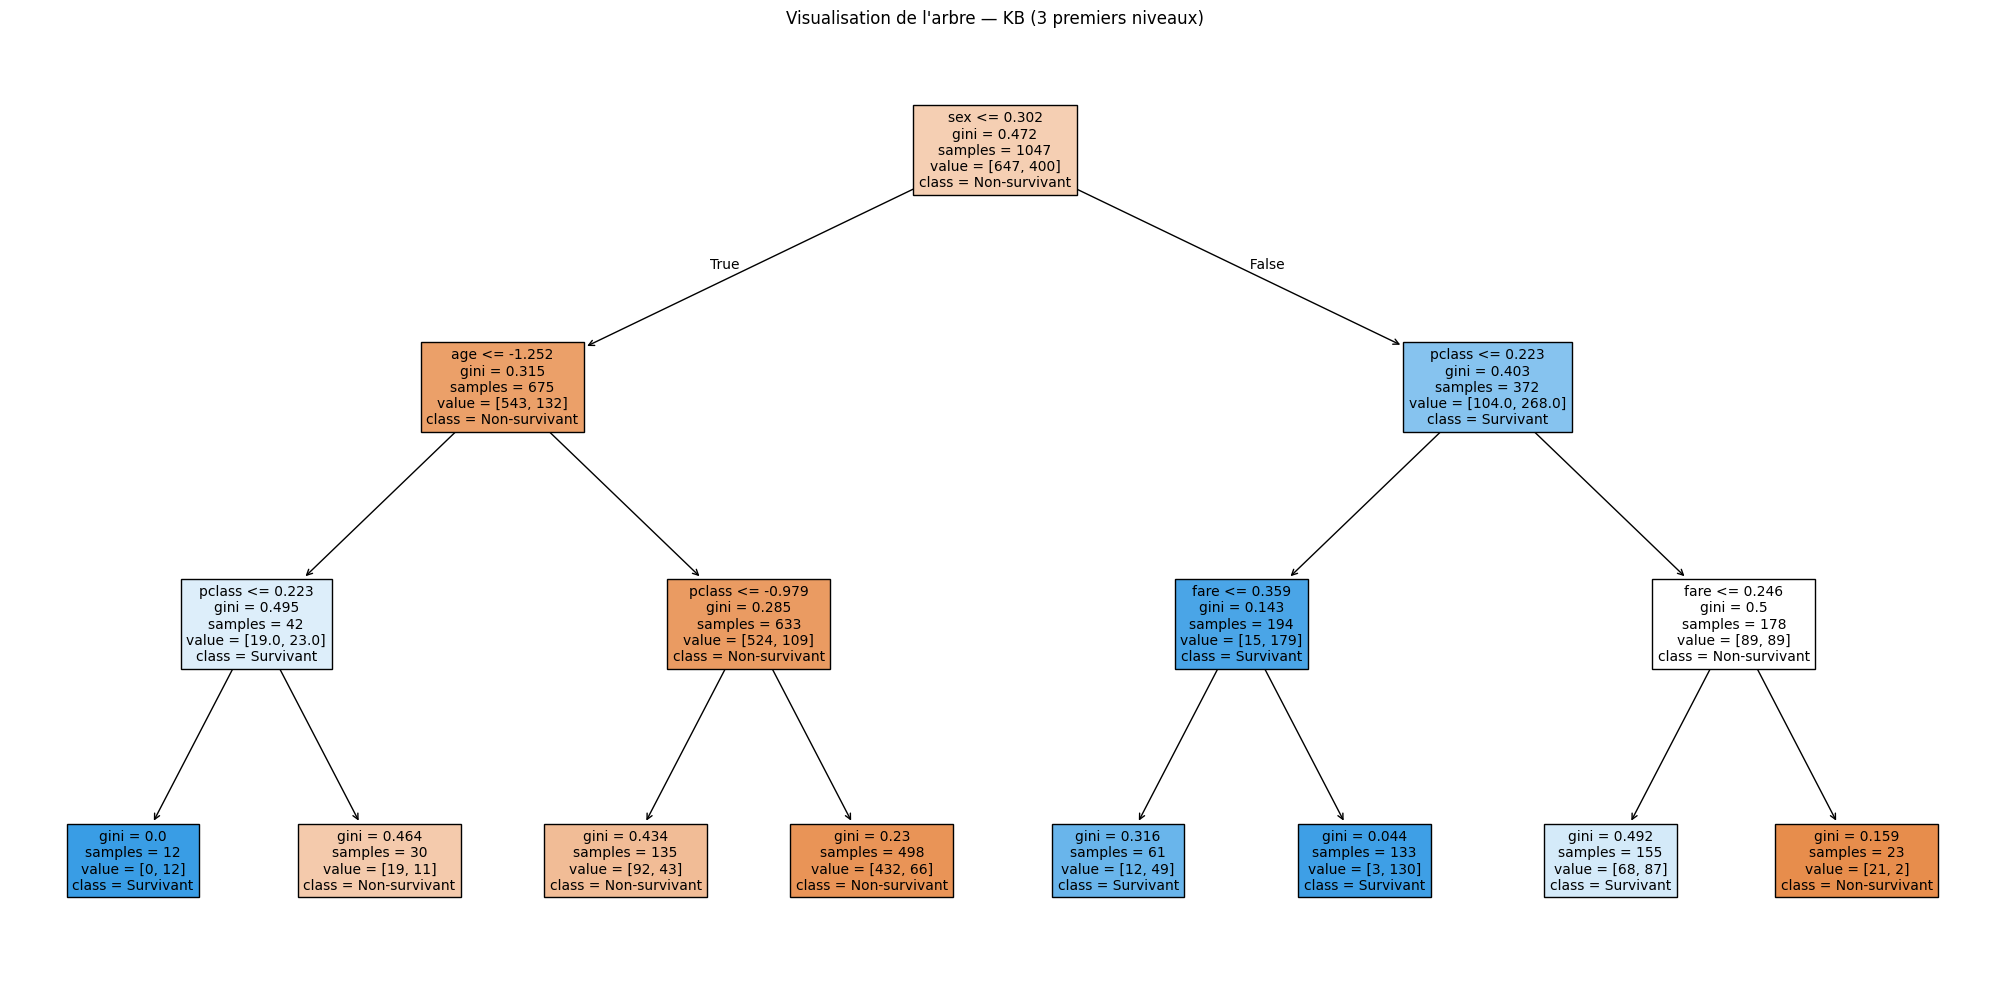

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=X_train.columns,
    class_names=['Non-survivant', 'Survivant'],
    filled=True,
    max_depth=3,
    fontsize=10
)
plt.title("Visualisation de l'arbre — KB (3 premiers niveaux)")
plt.tight_layout(); plt.show()

**Interprétation :** si `sex` et `pclass` ou `fare` apparaissent aux premiers noeuds, le modèle a bien capté les patterns historiques. Un arbre dont les premières règles sont cohérentes avec la réalité historique est un signe de bonne représentation des données — et facilite l'explication à un non-expert.